# Goal:
We are trying to run some experiments to understand the data and also make a baseline for our more refined tokenizer.
# Method:
1. create all the functions (like a splitter and corpus builder) to get a running pipeline
2. run some experiments and validate hypothesis
# Experiments
1. Run some tests to get an idea of the data. Like an n-gram tests to find frequently appearing subwords and to find which words are meaninglessly getting split
2. run some tests to validate hypothesises like , in the equations does % always appear with \, is i always iota or a subscript.



In [ ]:
import numpy as np
import pandas as pd
import os
import re
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


# Data split and extraction

In [ ]:
def splitter(text):
  parts = text.rsplit(":", 2) # assuming : doesnt appear in the amp and sq amp
  if len(parts) != 3:
    return None, None, None
  interaction = parts[0] #interaction plus feymnman diagram (We arent focusing on this right now)
  amp = parts[1].strip()
  sq_amp = parts[2].strip()
  return interaction, amp, sq_amp

# Building corpus

In [ ]:
def build_corpus(data_directory):
    """Loops through the Colab-connected Drive folder to build the dataset."""
    corpus = []

    # path validation
    if not os.path.exists(data_directory):
        print(f"Error: can't find a folder at '{data_directory}'")
        print("Check folder name and path")
        return corpus

    print(f"Scanning folder: {data_directory}...")

    for filename in os.listdir(data_directory):
        if filename.endswith(".txt"):
            filepath = os.path.join(data_directory, filename)

            with open(filepath, 'r', encoding='utf-8') as file:
                for line in file:
                    interaction, amp, sq_amp = splitter(line)

                    if amp and sq_amp:
                        corpus.append(amp)
                        corpus.append(sq_amp)

    print(f"Corpus built with {len(corpus)} total mathematical expressions.")
    return corpus

# Dataset loading

In [ ]:
drive_folder_path = '/content/drive/MyDrive/Symba'
my_corpus = build_corpus(drive_folder_path)
if my_corpus:
    print("\nSample Equation 1:", my_corpus[0][:100], "...")
    print("Sample Equation 2:", my_corpus[1][:100], "...")

Scanning folder: /content/drive/MyDrive/Symba...
Corpus built with 1188 total mathematical expressions.

Sample Equation 1: -1/2*i*e^2*gamma_{+%\tau_157,%gam_147,%eta_108}*gamma_{%\tau_157,%gam_148,%gam_149}*e_{l_3,%gam_147} ...
Sample Equation 2: 1/4*e^4*(16*m_e^2*m_t^2 + 8*m_e^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_t^2*s_34)*(m_t^2 + s_12 + 1 ...


# Experiments

### N-gram Test

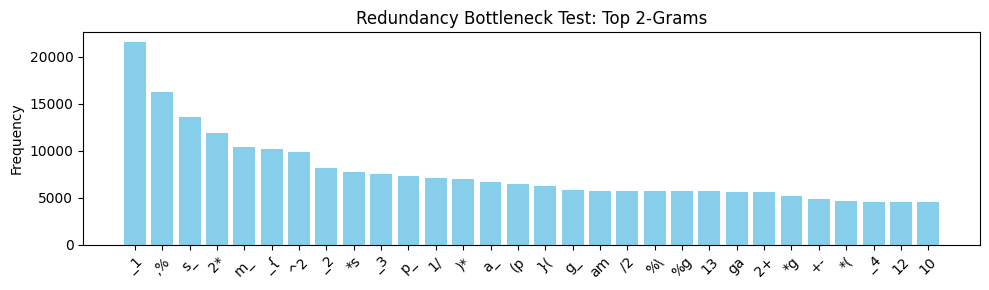

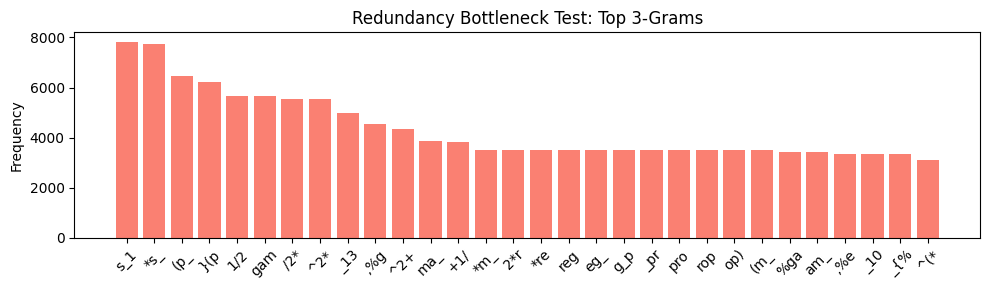

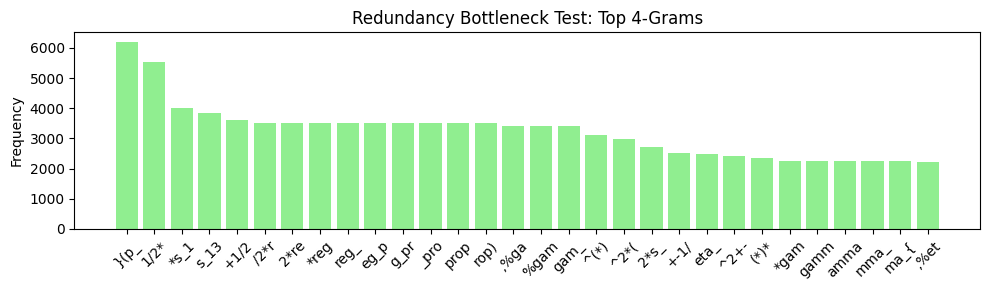

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

def run_ngram_bottleneck_test(corpus, top_k=30):
    """
    Breaks the equations into raw characters to find the most frequent
    statistical groupings (n-grams) across the entire QED/QCD dataset.
    """

    n_gram_counts = {2: Counter(), 3: Counter(), 4: Counter()}

    for eq in corpus:
        chars = [char for char in eq if char.strip()] #remove white-spaces

        # n-grams for n = 2, 3, 4
        for n in [2, 3, 4]:
            for i in range(len(chars) - n + 1):
                ngram = "".join(chars[i:i+n])
                n_gram_counts[n][ngram] += 1

   # ploting the results
    colors = ['skyblue', 'salmon', 'lightgreen']

    for idx, n in enumerate([2, 3, 4]):
        # Get the top K most common n-grams
        common = n_gram_counts[n].most_common(top_k)
        labels = [item[0] for item in common]
        values = [item[1] for item in common]

        plt.figure(figsize=(10, 3))

        plt.bar(labels, values, color=colors[idx])

        plt.title(f"Redundancy Bottleneck Test: Top {n}-Grams")
        plt.ylabel("Frequency")
        plt.xticks(rotation=45) # so that i can see the labels

        plt.tight_layout()
        plt.show()
    return n_gram_counts

ngram_stats = run_ngram_bottleneck_test(my_corpus)

### Redundant pair test

hypothesis: % and \ always appear together. IF no then i can pair them from the start, this will also act as a latex dummy flag and i will not let \ be an independent token in my vocabulary... other examples also exist.


In [ ]:
import re
from collections import Counter

def run_corpus_diagnostics(corpus):
    print("Backslash Test: ")
    total_bs = sum(eq.count('\\') for eq in corpus)
    percent_bs = sum(eq.count('%\\') for eq in corpus)
    lone_bs = total_bs - percent_bs

    print(f"Total '\\' found: {total_bs}")
    print(f"Attached to '%' (%\\): {percent_bs}")
    print(f"Lone '\\' (no %): {lone_bs}")

    if lone_bs > 0:
        print("instances of lone blackslash:")
        # Find \ followed by letters, NOT preceded by %
        examples = []
        for eq in corpus:
            examples.extend(re.findall(r'(?<!%)\\([a-zA-Z]+)', eq))

        print(f"  -> {list(set(examples))[:10]}")

    print("\nImaginary v/s index test: ")
    i_contexts = Counter()
    for eq in corpus:
        # Matches 'i' as a standalone letter and captures the 1 character right before it
        # if there is a _ before i then potentially its an index
        matches = re.findall(r'(.)i\b', eq)
        for match in matches:
            i_contexts[match] += 1

    print("Characters found immediately before 'i':")
    for char, count in i_contexts.most_common(8):
        if char == '_':
            print(f"  [_{char}] (Looks like an index): {count} times")
        elif char in [' ', '*', '+', '-', '(']:
            print(f"  ['{char}'] (Looks like imaginary unit): {count} times")
        else:
            print(f"  ['{char}'] (Other): {count} times")

    print("\n minus sign test ")
    minus_contexts = Counter()
    for eq in corpus:
        # Finds '-' and captures the first non-space character right before it
        matches = re.findall(r'([^\s])\s*-', eq)
        for match in matches:
            minus_contexts[match] += 1

    print("Characters found immediately BEFORE '-':")
    for char, count in minus_contexts.most_common(8):
        if char in ['=', '(', '*', '+']:
            print(f"  ['{char}'] (Likely Unary / Negative sign): {count} times")
        elif char.isalnum() or char in [')', '}', ']']:
            print(f"  ['{char}'] (Likely Binary / Subtraction): {count} times")
        else:
            print(f"  ['{char}'] (Other context): {count} times")

# Run it on your data!
run_corpus_diagnostics(my_corpus)

Backslash Test: 
Total '\' found: 5712
Attached to '%' (%\): 5712
Lone '\' (no %): 0

Imaginary v/s index test: 
Characters found immediately before 'i':
  ['*'] (Looks like imaginary unit): 2364 times
  ['('] (Looks like imaginary unit): 583 times
  ['-'] (Looks like imaginary unit): 359 times
  [' '] (Looks like imaginary unit): 141 times

 minus sign test 
Characters found immediately BEFORE '-':
  ['+'] (Likely Unary / Negative sign): 4874 times
  ['('] (Likely Unary / Negative sign): 3101 times


# Parsing
normalizing indices otherwise vocabulary will burst.

Key issues :
1. dummy variables like gamma_234 has the same meaning as gamma_1 as they undergo the same operation. The model may try to get meaning out of indice which is senseless
2. if parsing happens only from left to right then the model will need to explicitly learn that commutability exists for some operations
3. long range dependencies
# approach?
1. i cant just replace _234 with _1 from left to right. the model might assume these dummy variables are part of actual physics variable
2. so i tag the dummy variable indice with _d1 so that it doesnt connfuse it with the real variable indices


In [ ]:
import re

def perfect_standardizer(expression): # emphasis on the perfect :)
    """
    Uses the user's '%' logic to perfectly identify and standardize
    dummy variables without touching actual physical kinematics.
    """
    mapping = {}
    dummy_counter = 1

    def replacer(match):
        nonlocal dummy_counter
        # Group 1 captures the prefix, e.g., "%\sigma_" or "%\mu_"
        prefix = match.group(1)
        # Group 2 captures the actual number, e.g., "18923"
        index_str = match.group(2)

        # RULE 1: Have we mapped this dummy number before?
        if index_str in mapping:
            return f"{prefix}{mapping[index_str]}"

        # RULE 2: Brand new dummy number! Assign it a 'd' label.
        new_id = f"d{dummy_counter}"
        mapping[index_str] = new_id
        dummy_counter += 1

        return f"{prefix}{new_id}"

    # THE MAGIC REGEX:
    # Looks for a '%' sign, then any letters/symbols, then an '_', then a number.
    # It strictly ONLY triggers if the '%' sign is present.
    standardized_expr = re.sub(r'(%[a-zA-Z\\]+_)(\d+)', replacer, expression)

    return standardized_expr

# --- LET'S TEST YOUR LOGIC ---
# Notice we have a 2-digit dummy (%mu_99), physical vars (p_1, s_12), and a big dummy
test_eq = "s_12 * gamma_{%\\sigma_18923} * p_1 + delta_{%\\mu_99} * gamma_{%\\sigma_18923}"

print("Original:", test_eq)
print("Cleaned: ", perfect_standardizer(test_eq))

Original: s_12 * gamma_{%\sigma_18923} * p_1 + delta_{%\mu_99} * gamma_{%\sigma_18923}
Cleaned:  s_12 * gamma_{%\sigma_d1} * p_1 + delta_{%\mu_d2} * gamma_{%\sigma_d1}


In [ ]:
standardized_corpus = [perfect_standardizer(eq) for eq in my_corpus]

# --- VALIDATION CHECK ---
print("--- VALIDATION ---")
for i in range(2):
    print(f"Original {i+1}:", my_corpus[i])
    print(f"Cleaned  {i+1}:", standardized_corpus[i])
    print("-")

--- VALIDATION ---
Original 1: -1/2*i*e^2*gamma_{+%\tau_157,%gam_147,%eta_108}*gamma_{%\tau_157,%gam_148,%gam_149}*e_{l_3,%gam_147}(p_3)_u^(*)*e_{j_5,%eta_108}(p_4)_v*t_{i_3,%gam_149}(p_1)_u*t_{k_3,%gam_148}(p_2)_v^(*)/(m_t^2 + s_12 + 1/2*reg_prop)
Cleaned  1: -1/2*i*e^2*gamma_{+%\tau_d1,%gam_d2,%eta_d3}*gamma_{%\tau_d1,%gam_d4,%gam_d5}*e_{l_3,%gam_d2}(p_3)_u^(*)*e_{j_5,%eta_d3}(p_4)_v*t_{i_3,%gam_d5}(p_1)_u*t_{k_3,%gam_d4}(p_2)_v^(*)/(m_t^2 + s_12 + 1/2*reg_prop)
-
Original 2: 1/4*e^4*(16*m_e^2*m_t^2 + 8*m_e^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_t^2*s_34)*(m_t^2 + s_12 + 1/2*reg_prop)^(-2)
Cleaned  2: 1/4*e^4*(16*m_e^2*m_t^2 + 8*m_e^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_t^2*s_34)*(m_t^2 + s_12 + 1/2*reg_prop)^(-2)
-


In [ ]:
import os

file_name = 'qed_training_data.txt'

# Write the standardized list to a text file, one equation per line
with open(file_name, 'w', encoding='utf-8') as f:
    for eq in standardized_corpus:
        f.write(eq + '\n')
# Validation Test
print("VALIDATION:")
print(f"File '{file_name}' created successfully.")
with open(file_name, 'r', encoding='utf-8') as f:
    print("First 2 lines physically written in the file:")
    print(f.read().splitlines()[:2])

VALIDATION:
File 'qed_training_data.txt' created successfully.
First 2 lines physically written in the file:
['-1/2*i*e^2*gamma_{+%\\tau_d1,%gam_d2,%eta_d3}*gamma_{%\\tau_d1,%gam_d4,%gam_d5}*e_{l_3,%gam_d2}(p_3)_u^(*)*e_{j_5,%eta_d3}(p_4)_v*t_{i_3,%gam_d5}(p_1)_u*t_{k_3,%gam_d4}(p_2)_v^(*)/(m_t^2 + s_12 + 1/2*reg_prop)', '1/4*e^4*(16*m_e^2*m_t^2 + 8*m_e^2*s_12 + 8*s_14*s_23 + 8*s_13*s_24 + 8*m_t^2*s_34)*(m_t^2 + s_12 + 1/2*reg_prop)^(-2)']


# Making VIP List

In [ ]:
# 1. Base VIPs (The core structure)
base_vips = ['s_12', 's_13', 's_14', 's_23', 's_24', 's_34', 'reg_prop', '1/2', 'i', '%\\']

# 2. Physics & Math VIPs (Force the tokenizer to respect physics!)
physics_vips = [
    'gamma', 'alpha', 'beta', 'rho', 'sigma', 'eta', 'eps', 'mu', 'nu', 'tau', 'lambda',
    'AntiPart', 'Vertex', 'OffShell', 'm_b^2', 'g^2', 'g^4'
]

# 3. Dummy protections (d1 through d100)
dummy_vips = [f"d{num}" for num in range(1, 101)]

# 4. Combine into the master list
master_vip_list = base_vips + physics_vips + dummy_vips

print(f"Total VIPs protected: {len(master_vip_list)}")
print("Physics terms locked in:", physics_vips)

Total VIPs protected: 127
Physics terms locked in: ['gamma', 'alpha', 'beta', 'rho', 'sigma', 'eta', 'eps', 'mu', 'nu', 'tau', 'lambda', 'AntiPart', 'Vertex', 'OffShell', 'm_b^2', 'g^2', 'g^4']


In [ ]:
file_name = 'qed_training_data.txt'

try:
    with open(file_name, 'r', encoding='utf-8') as f:
        lines = f.readlines()

    print(f"HARD CHECK: There are exactly {len(lines)} equations in the text file.")

    if len(lines) > 0:
        print(f"Total characters in the file: {sum(len(line) for line in lines)}")

except FileNotFoundError:
    print(f"ERROR: The file '{file_name}' does not exist on the drive!")

HARD CHECK: There are exactly 1188 equations in the text file.
Total characters in the file: 608927


In [ ]:
import sentencepiece as spm


vocab_size = 1500


train_args = (
    f"--input=qed_training_data.txt "
    f"--model_prefix=qed_unigram_model "
    f"--vocab_size={vocab_size} "
    f"--model_type=unigram "           #unigram
    f"--split_digits=true "
    f"--character_coverage=1.0 "
    f"--hard_vocab_limit=false "
    f"--user_defined_symbols={','.join(master_vip_list)}"
)

# Train the top-down model
spm.SentencePieceTrainer.train(train_args)

# validation
print("VALIDATION:")
print("Training complete, Model saved as 'qed_unigram_model.model'")

VALIDATION:
Training complete, Model saved as 'qed_unigram_model.model'


In [ ]:


sp = spm.SentencePieceProcessor(model_file='qed_unigram_model.model')

# Edge-Case Test Equation
test_equation = "s_12 * gamma_{%\\sigma_d1} + AntiPart * m_b^2"

# Tokenization
tokens = sp.encode(test_equation, out_type=str)

print("--- VALIDATION METRICS ---")
print("Input       :", test_equation)
print("Tokens      :", tokens)
print("Fertility   :", len(tokens), "tokens used")

--- VALIDATION METRICS ---
Input       : s_12 * gamma_{%\sigma_d1} + AntiPart * m_b^2
Tokens      : ['▁', 's_12', '▁', '*', '▁', 'gamma', '_{', '%\\', 'sigma', '_', 'd1', '}', '▁', '+', '▁', 'AntiPart', '▁', '*', '▁', 'm_b^2']
Fertility   : 20 tokens used


In [ ]:
# Print the top 30 tokens the AI learned (skipping our VIPs which have score 0.0)
learned_tokens = [(sp.id_to_piece(id), sp.get_score(id)) for id in range(sp.get_piece_size()) if sp.get_score(id) < 0]

print("--- TOP 30 AI-DISCOVERED TOKENS ---")
for token, score in learned_tokens[:30]:
    print(f"{token} : {score}")

--- TOP 30 AI-DISCOVERED TOKENS ---
_ : -1.1715521812438965
* : -2.8450605869293213
▁ : -2.8956055641174316
+ : -3.1402461528778076
,% : -3.1868271827697754
2 : -3.297714948654175
1 : -3.5149762630462646
m : -3.7027015686035156
_{ : -3.8390300273895264
p : -3.9649596214294434
^ : -3.9702587127685547
4 : -4.002310276031494
( : -4.03472900390625
} : -4.071661949157715
g : -4.101308345794678
) : -4.277230739593506
▁- : -4.293150424957275
3 : -4.304874897003174
8 : -4.362670421600342
)* : -4.555650234222412
6 : -4.567229747772217
0 : -4.586444854736328
*( : -4.6282877922058105
u : -4.652953147888184
}* : -4.693756103515625
a : -4.714554309844971
d : -4.87270975112915
e : -4.893116474151611
l : -4.9451494216918945
)_ : -5.007665157318115


#Conclusion
### Key Limitations of Standard NLP Tokenization

1. The learned vocabulary stubbornly resisted semantic coherence — most tokens ended up capturing fragmented operator patterns rather than anything resembling meaningful physics structure.

2. Bracket-heavy infix notation proved to be a particularly nasty adversary: the tokenizer had no way to recover the hierarchical and compositional structure buried inside, making the representation learning task harder than it ever needed to be.
3. Mathematically equivalent expressions continued to produce entirely different token sequences (e.g. (2*(3+5)) vs ((5+3)*2)), breaking the structural consistency that any reliable symbolic mapping fundamentally depends on.

###Important Observations & Improvements

1. A robust dummy-index normalization scheme was developed that swaps out unwieldy indices (like _123456) for compact, shared identifiers (d1, d2, ...) — a small change that went a long way in taming vocabulary explosion.
2. N-gram analysis surfaced regions of excessive fragmentation, allowing frequently recurring physics terms (like sigma) to be shielded from the tokenizer's chopping block via a manually curated VIP token list.
3. Redundant-pair analysis offered independent validation of several structural hypotheses around operator usage and symbol co-occurrence, opening further avenues for vocabulary simplification.

#Final Insight
Statistical subword methods can trim sequence length — but they do so at the cost of structural semantics, which symbolic mathematics and physics expressions simply cannot afford to lose.


This points clearly toward grammar-aware parsing and structure-preserving representations:

approaches capable of eliminating brackets entirely while still faithfully maintaining hierarchy, identity, and deterministic symbolic mappings.





